# Fase 1: Exploratieve Data Analyse (EDA)
## Kadaster - Automatisering Rechtsfeiten Herkenning

Doel: Begrijpen van de dataset en deze gereedmaken voor het model.

### Analysepunten:
1. Distributie check: Class imbalance identificeren
2. Lengte analyse: Tekstlengtes voor BERT modellen (512 token limiet)
3. Kwaliteitscheck: Label consistentie
4. Top 20 labels coverage analyse

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.data_loader import jsonl_to_dataframe, get_data_statistics, print_statistics

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Laden

In [2]:
# Load data
data_path = "../ai-challenge-data_ai_challenge_data_anonymized_19744.jsonl"
df = jsonl_to_dataframe(data_path)

print(f"Loaded {len(df)} documents")
df.head()

Loaded 19744 documents


,akteId,text,rechtsfeitcodes
0,a652b686-d910-4044-abc5-e2dd91aeb131,Verklaring: Het bijgevoegde stuk is ingeschrev...,"[585, 564]"
1,ec9064d7-38eb-4aeb-827f-40b1d963501d,LEVERING Project * te Apeldoorn 56127TB Vandaa...,"[545, 572, 606]"
2,df3bbc5c-a7c6-4701-93ba-1612708b9519,"* 216690018 HYPOTHEEK Heden, zeventien februar...",[537]
3,0c3d9c94-8817-424f-b62f-383e01dcb545,"Registerverklaring QVL/569678 Ondergetekende, ...",[524]
4,a032c64a-ff9d-4884-91f9-fa2ac53cda7b,*: WQ/wch/6872.8128.51 AKTE VAN LEVERING VAN A...,"[606, 671]"


## 2. Basis Statistieken

In [3]:
stats = get_data_statistics(df)
print_statistics(stats)

DATASET STATISTICS

Document Statistics:
  Total documents: 19,744
  Average text length: 22,058 characters
  Median text length: 18,012 characters
  Min text length: 1,602 characters
  Max text length: 362,924 characters
  Average word count: 3,247 words

Label Statistics:
  Total label occurrences: 24,962
  Unique labels: 86
  Average labels per document: 1.26
  Min labels per document: 1
  Max labels per document: 6

Label Distribution (Top 20):
Label           Count      Percentage
----------------------------------------
606             8141       32.61%
537             4827       19.34%
585             1901       7.62%
545             1844       7.39%
572             1287       5.16%
564             874        3.50%
527             583        2.34%
532             565        2.26%
538             541        2.17%
580             425        1.70%
581             390        1.56%
644             311        1.25%
543             276        1.11%
516             229        0.92%
517 

## 3. Label Distributie Analyse
### Checking voor class imbalance

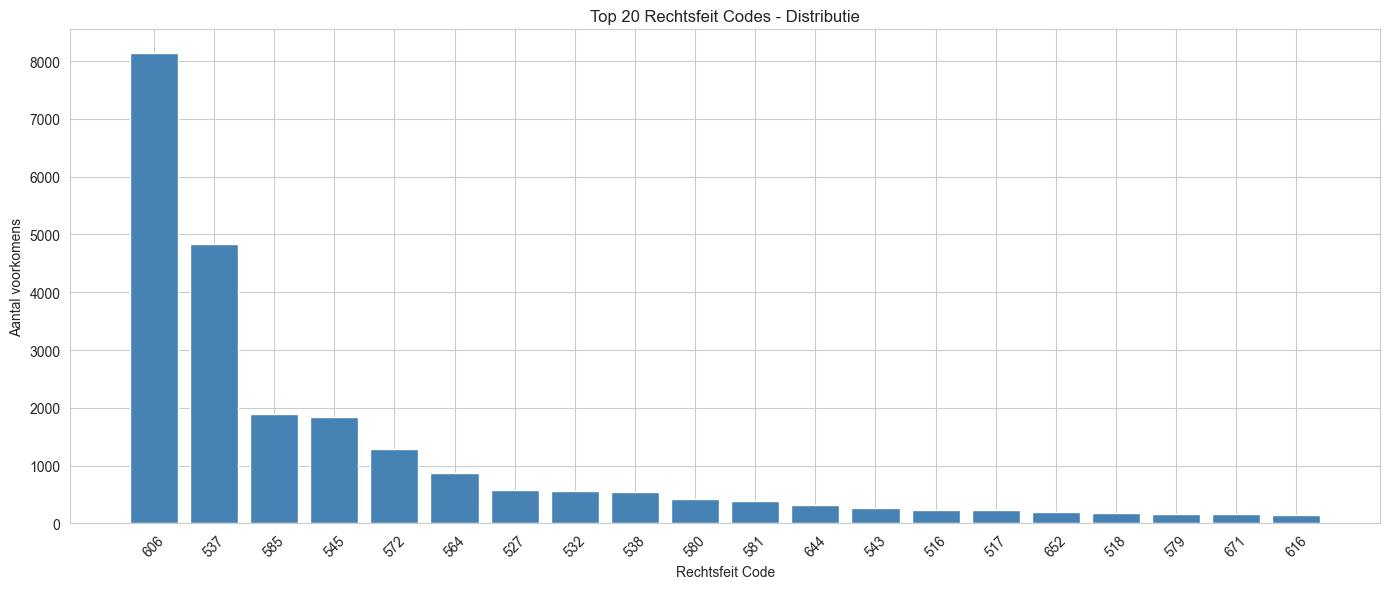


Top 20 Labels Coverage Analysis:
Rank   Label      Count      %        Cumulative %   
------------------------------------------------------------
1      606        8141       32.61    32.61          
2      537        4827       19.34    51.95          
3      585        1901       7.62     59.57          
4      545        1844       7.39     66.95          
5      572        1287       5.16     72.11          
6      564        874        3.50     75.61          
7      527        583        2.34     77.95          
8      532        565        2.26     80.21          
9      538        541        2.17     82.38          
10     580        425        1.70     84.08          
11     581        390        1.56     85.64          
12     644        311        1.25     86.89          
13     543        276        1.11     87.99          
14     516        229        0.92     88.91          
15     517        225        0.90     89.81          
16     652        192        0.77     90.

In [4]:
# Get all labels
all_labels = []
for labels in df['rechtsfeitcodes']:
    all_labels.extend(labels)

label_counts = Counter(all_labels)

# Top 20 labels
top_20_labels = label_counts.most_common(20)
labels, counts = zip(*top_20_labels)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(range(len(labels)), counts, color='steelblue')
plt.xlabel('Rechtsfeit Code')
plt.ylabel('Aantal voorkomens')
plt.title('Top 20 Rechtsfeit Codes - Distributie')
plt.xticks(range(len(labels)), labels, rotation=45)
plt.tight_layout()
plt.show()

# Calculate cumulative coverage
total_labels = len(all_labels)
cumulative_coverage = 0
print("\nTop 20 Labels Coverage Analysis:")
print(f"{'Rank':<6} {'Label':<10} {'Count':<10} {'%':<8} {'Cumulative %':<15}")
print("-" * 60)
for i, (label, count) in enumerate(top_20_labels, 1):
    percentage = (count / total_labels) * 100
    cumulative_coverage += percentage
    print(f"{i:<6} {label:<10} {count:<10} {percentage:<8.2f} {cumulative_coverage:<15.2f}")

## 4. Tekstlengte Analyse
### Belangrijk voor BERT models (512 token limiet)

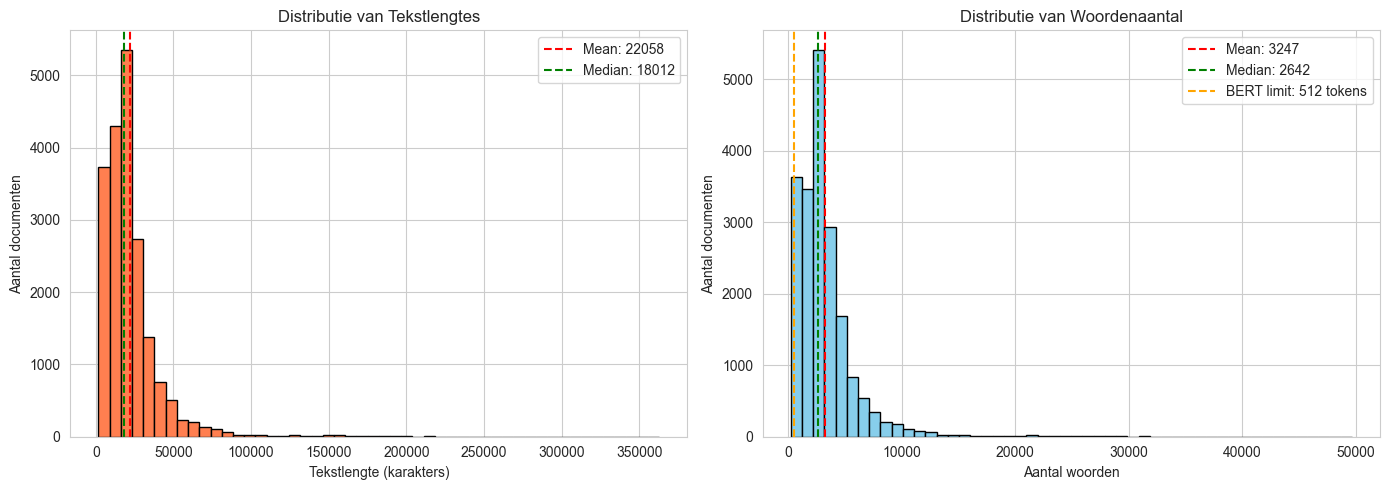


Documenten langer dan 512 woorden: 18626 (94.3%)


In [5]:
# Plot text length distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['text_length'], bins=50, color='coral', edgecolor='black')
plt.xlabel('Tekstlengte (karakters)')
plt.ylabel('Aantal documenten')
plt.title('Distributie van Tekstlengtes')
plt.axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_length"].mean():.0f}')
plt.axvline(df['text_length'].median(), color='green', linestyle='--', label=f'Median: {df["text_length"].median():.0f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Aantal woorden')
plt.ylabel('Aantal documenten')
plt.title('Distributie van Woordenaantal')
plt.axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
plt.axvline(df['word_count'].median(), color='green', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
# Add 512 token reference line
plt.axvline(512, color='orange', linestyle='--', label='BERT limit: 512 tokens')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nDocumenten langer dan 512 woorden: {(df['word_count'] > 512).sum()} ({(df['word_count'] > 512).sum() / len(df) * 100:.1f}%)")

## 5. Multi-label Analyse
### Hoeveel documenten hebben meerdere labels?

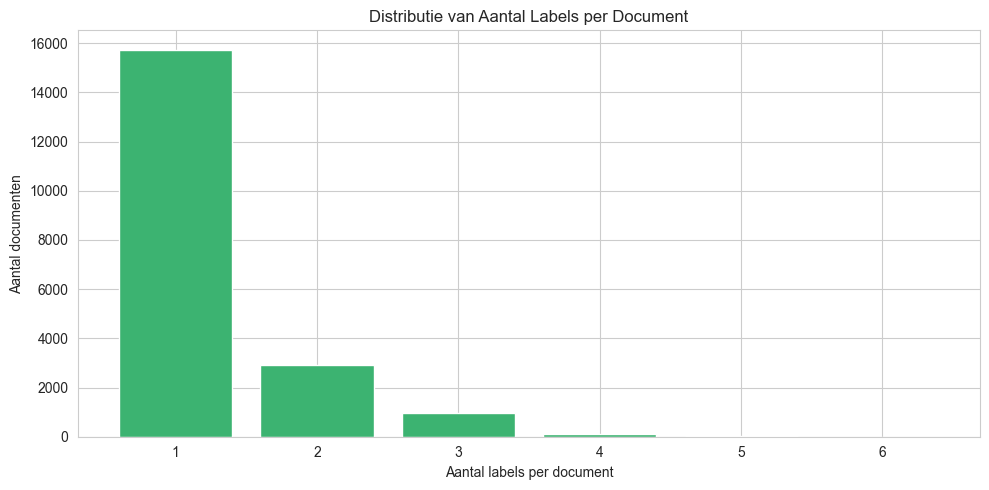


Multi-label statistieken:
  1 label(s): 15,736 documenten (79.70%)
  2 label(s): 2,931 documenten (14.85%)
  3 label(s): 960 documenten (4.86%)
  4 label(s): 102 documenten (0.52%)
  5 label(s): 14 documenten (0.07%)
  6 label(s): 1 documenten (0.01%)


In [6]:
# Number of labels per document
label_count_dist = df['num_labels'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(label_count_dist.index, label_count_dist.values, color='mediumseagreen')
plt.xlabel('Aantal labels per document')
plt.ylabel('Aantal documenten')
plt.title('Distributie van Aantal Labels per Document')
plt.xticks(label_count_dist.index)
plt.tight_layout()
plt.show()

print("\nMulti-label statistieken:")
for num_labels, count in label_count_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {num_labels} label(s): {count:,} documenten ({percentage:.2f}%)")

## 6. Conclusies EDA

Belangrijkste bevindingen:

1. **Class Imbalance**: Er is significante class imbalance. Top labels domineren.
2. **Tekstlengte**: Documenten zijn zeer lang (gemiddeld ~3200 woorden). Vrijwel alle documenten overschrijden de 512 token limiet van BERT.
3. **Multi-label**: Meeste documenten hebben 1 label, maar er zijn ook multi-label cases.
4. **Top 20 Coverage**: De top 20 labels dekken waarschijnlijk >90% van de data.

### Implicaties voor Modellering:
- Voor baseline model: TF-IDF kan volledige tekst gebruiken (geen token limiet)
- Voor BERT: We moeten een strategie implementeren (eerste 512 tokens, sliding window, of samenvatting)
- Class imbalance: We moeten stratified splitting gebruiken
- Multi-label: We kunnen starten met single-label benadering voor simpliciteit

## 7. Sample Document Inspection

In [7]:
# Look at a sample document
sample = df.iloc[0]
print(f"Akte ID: {sample['akteId']}")
print(f"Rechtsfeit Codes: {sample['rechtsfeitcodes']}")
print(f"Text length: {sample['text_length']} chars")
print(f"Word count: {sample['word_count']} words")
print(f"\nFirst 500 characters of text:\n{sample['text'][:500]}...")

Akte ID: a652b686-d910-4044-abc5-e2dd91aeb131
Rechtsfeit Codes: [585, 564]
Text length: 4704 chars
Word count: 665 words

First 500 characters of text:
Verklaring: Het bijgevoegde stuk is ingeschreven ten kantore van de Dienst voor het Kadaster en de Openbare Registers op 20-03-2018 om 09:00 in register Onroerende Zaken Hyp4 in deel 38611 nummer 183. De bewaarder. Heden, zevenentwintig augustus tweeduizend eenentwintig, verklaar ik, Ing Kok, toegevoegd notaris, bevoegd om akten te passeren in het protocol van Lec Dirk Roelse, notaris met plaats van vestiging Leiden, dat ik mij zoveel mogelijk heb overtuigd van het volgende: Overlijden Op eenent...
